<a href="https://colab.research.google.com/github/agulhane090398/PythonViz/blob/main/Text_Representation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# libraries to display dataframe and images
from IPython.display import display
from PIL import Image
# matplotlib for vizualization
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# inbuild library to work with textual data
import string
# Setting up the NLTK to pre-processing textual data
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, LancasterStemmer, SnowballStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize, sent_tokenize
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('tagsets')
nltk.download('universal_tagset')
nltk.download('treebank')

sns.set_theme(style="darkgrid")
pd.set_option("display.max_columns", 100)
%matplotlib inline

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package tagsets to /root/nltk_data...
[nltk_data]   Unzipping help/tagsets.zip.
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.
[nltk_data] Downloading package treebank to /root/nltk_data...
[nltk_data]   Unzipping corpora/treebank.zip.


In [ ]:
!gdown 1MyOEKk_z78P8JL0mTYSerRiPLVflkVK6 # Downloading data


Downloading...
From: https://drive.google.com/uc?id=1MyOEKk_z78P8JL0mTYSerRiPLVflkVK6
To: /content/medium_articles_v3.csv
100% 3.13M/3.13M [00:00<00:00, 104MB/s]


In [ ]:
import numpy as np
import pandas as pd
import spacy
from spacy import displacy

# reading the csv data file
articles = pd.read_csv("/content/medium_articles_v3.csv")
display(articles.head(10))
print("Shape of dataframe : {}".format(articles.shape))

,link,title,sub_title,author,reading_time,text,id
0,https://towardsdatascience.com/ensemble-method...,"Ensemble methods: bagging, boosting and stacking",Understanding the key concepts of ensemble lea...,Joseph Rocca,20,This post was co-written with Baptiste Rocca.\...,1
1,https://towardsdatascience.com/understanding-a...,Understanding AUC - ROC Curve,"In Machine Learning, performance measurement i...",Sarang Narkhede,5,"In Machine Learning, performance measurement i...",2
2,https://towardsdatascience.com/how-to-work-wit...,How to work with object detection datasets in ...,"A comprehensive guide to defining, loading, ex...",Eric Hofesmann,10,Microsoft's Common Objects in Context dataset ...,3
3,https://towardsdatascience.com/11-dimensionali...,11 Dimensionality reduction techniques you sho...,Reduce the size of your dataset while keeping ...,Rukshan Pramoditha,16,"In both Statistics and Machine Learning, the n...",4
4,https://towardsdatascience.com/the-time-series...,The Time Series Transformer,Attention Is All You Need they said. Is it a m...,Theodoros Ntakouris,6,Attention Is All You Need they said. Is it a m...,5
5,https://netflixtechblog.com/learning-a-persona...,Learning a Personalized Homepage,how to best tailor each member's homepage to m...,Netflix Technology Blog,15,by Chris Alvino and Justin Basilico\nAs we've ...,6
6,https://towardsdatascience.com/6-data-science-...,6 Data Science Certificates To Level Up Your C...,Pump up your portfolio and get closer to your ...,Sara A. Metwalli,6,Because of the appeal of the field of data sci...,7
7,https://towardsdatascience.com/transformers-ex...,Transformers Explained Visually (Part 2): How ...,A Gentle Guide to the Transformer under the ho...,Ketan Doshi,11,This is the second article in my series on Tra...,8
8,https://medium.com/coders-camp/60-python-proje...,60 Python Projects with Source Code,60 Python Projects with Source code solved and...,Aman Kharwal,2,Python has been in the top 10 popular programm...,9
9,https://towardsdatascience.com/geometric-found...,Geometric foundations of Deep Learning,Geometric Deep Learning is an attempt to unify...,Michael Bronstein,13,This blog post was co-authored with Joan Bruna...,10


Shape of dataframe : (208, 7)


In [ ]:
from pprint import pprint

pprint(articles.iloc[0].to_dict(), compact=True)

{'author': 'Joseph Rocca',
 'id': 1,
 'link': 'https://towardsdatascience.com/ensemble-methods-bagging-boosting-and-stacking-c9214a10a205?source=tag_archive---------5-----------------------',
 'reading_time': 20,
 'sub_title': 'Understanding the key concepts of ensemble learning.',
 'text': 'This post was co-written with Baptiste Rocca.\n'
         '"Unity is strength". This old saying expresses pretty well the '
         'underlying idea that rules the very powerful "ensemble methods" in '
         'machine learning. Roughly, ensemble learning methods, that often '
         'trust the top rankings of many machine learning competitions '
         "(including Kaggle's competitions), are based on the hypothesis that "
         'combining multiple models together can often produce a much more '
         'powerful model.\n'
         'The purpose of this post is to introduce various notions of ensemble '
         'learning. We will give the reader some necessary keys to well '
         'und

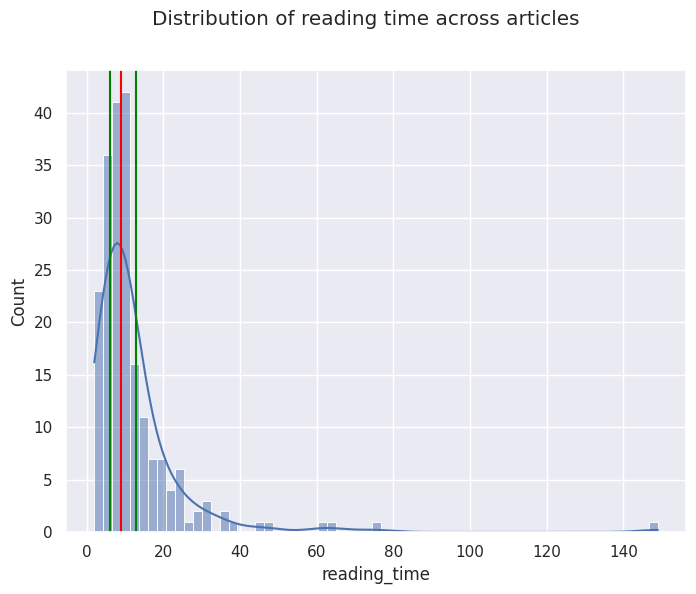

In [ ]:
# ditsribution of reading times in our corpus
fig, axes = plt.subplots(figsize = (8, 6))
# creating histograms
sns.histplot(articles["reading_time"], kde=True, ax = axes)
# Computing percentile of the reading_time data.
first_q = np.percentile(articles["reading_time"], 25)
# Computing median (50th percentile) of the reading_time data.
second_q = np.percentile(articles["reading_time"], 50)
third_q = np.percentile(articles["reading_time"], 75)
# green lines for 25th and 75th percentile
plt.axvline(first_q, color = "green")
# red line for median reading_time
plt.axvline(second_q, color = "red")
plt.axvline(third_q, color = "green")
# plot title
plt.suptitle("Distribution of reading time across articles")
plt.show()


In [ ]:
articles["reading_time"].median()

9.0

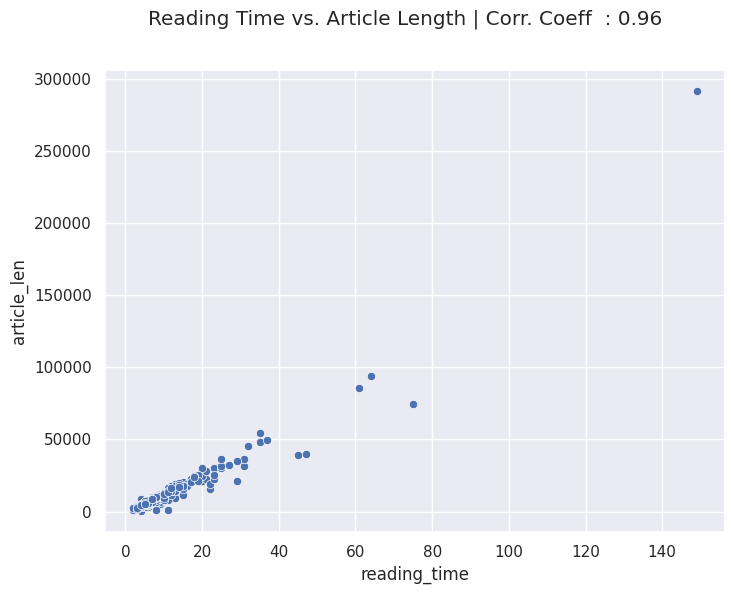

In [ ]:
from scipy.stats import pearsonr

articles["article_len"] = articles["text"].apply(lambda x : len(x))
# creating scatterplot
fig, axes = plt.subplots(figsize = (8, 6))
sns.scatterplot(x = articles["reading_time"], y = articles["article_len"])
# Pearson correlation coefficient measures the linear relationship between two set of values.
corr_coeff, _ = pearsonr(articles["reading_time"], articles["article_len"])
# plot title
plt.suptitle("Reading Time vs. Article Length | Corr. Coeff  : {}".format(round(corr_coeff, 2)))
plt.show()

In [ ]:
for author, count in dict(articles["author"].value_counts()).items():
    if(count < 2):
        continue
    print("Articles by {} :".format(author))
    for title in articles[articles["author"] == author]["title"].values:
        print(title)
    print("-"*120)

Articles by Adam Geitgey :
Machine Learning is Fun Part 5: Language Translation with Deep Learning and the Magic of Sequences
Machine Learning is Fun! Part 4: Modern Face Recognition with Deep Learning
Machine Learning is Fun! Part 3: Deep Learning and Convolutional Neural Networks
Machine Learning is Fun! Part 2
Machine Learning is Fun Part 6: How to do Speech Recognition with Deep Learning
------------------------------------------------------------------------------------------------------------------------
Articles by Joseph Rocca :
Ensemble methods: bagging, boosting and stacking
Understanding Variational Autoencoders (VAEs)
Understanding Generative Adversarial Networks (GANs)
------------------------------------------------------------------------------------------------------------------------
Articles by Natassha Selvaraj :
I tripled my income with data science. Here's how.
How to Land a Data Analytics Job in 6 Months
Top 10 Data Science Projects for Beginners
-----------------

In [ ]:
#Pre- Processing


sample_text = """
I've decided to go to the party after all. I'll reach by 05:00 PM.
He's not coming with us.
It's his birthday and he has other plans.
They've thought about going to the movies.
I won't be going to movies.
"""

In [ ]:
custom_mapping = {
    "n't" : " not",
    "'re" : " are",
    "'ve" : " have",
    "'ll" : " will",
    "'m" : " am"
}

In [ ]:
import re
expanded_text = sample_text
for x in custom_mapping.keys():
    expanded_text = re.sub(x, custom_mapping[x], expanded_text)

print(expanded_text)


I have decided to go to the party after all. I will reach by 05:00 PM.
He's not coming with us.
It's his birthday and he has other plans.
They have thought about going to the movies.
I wo not be going to movies.



In [ ]:
!pip install contractions


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.8 MB/s eta 0:00:00


In [ ]:
import contractions

print(contractions.fix(sample_text))


I have decided to go to the party after all. I will reach by 05:00 PM.
He is not coming with us.
It is his birthday and he has other plans.
They have thought about going to the movies.
I will not be going to movies.



In [ ]:
from sklearn.preprocessing import OneHotEncoder
import itertools
# two example documents
docs = ["cat","dog","bat","ate","lion","dog","bat"]
# split documents to tokens
tokens_docs = [doc.split(" ") for doc in docs]
# convert list of of token-lists to one flat list of tokens
# and then create a dictionary that maps word to id of word,
all_tokens = itertools.chain.from_iterable(tokens_docs)
word_to_id = {token: idx for idx, token in enumerate(set(all_tokens))}
# convert token lists to token-id lists
token_ids = [[word_to_id[token] for token in tokens_doc] for tokens_doc in tokens_docs]
# convert list of token-id lists to one-hot representation
vec = OneHotEncoder(categories="auto")
X = vec.fit_transform(token_ids)
print(X.toarray())

[[0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]]


In [ ]:
from sklearn.preprocessing import OneHotEncoder
import itertools
# two example documents
docs = ["cat","dog","bat","ate","lion","dog","bat"]
# split documents to tokens
tokens_docs = [doc.split(" ") for doc in docs]
# convert list of of token-lists to one flat list of tokens
# and then create a dictionary that maps word to id of word,
all_tokens = itertools.chain.from_iterable(tokens_docs)
word_to_id = {token: idx for idx, token in enumerate(set(all_tokens))}
# convert token lists to token-id lists
token_ids = [[word_to_id[token] for token in tokens_doc] for tokens_doc in tokens_docs]
token_ids

[[2], [4], [3], [0], [1], [4], [3]]

In [ ]:
corpus = [
    "it was the best of times",
    "it was the worst of times",
    "it was the age of wisdom and the age of foolishness"
]


In [ ]:
# Using CountVectorizer from scikit-learn
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
# Learn the vocabulary dictionary and return document-term matrix
bow_rep = cv.fit_transform(corpus).todense()  # todense() returns a matrix
# create dataframe
df = pd.DataFrame(bow_rep)
# Get output feature names for dataframe columns.
df.columns = cv.get_feature_names_out()
df.index = corpus
display(df)

,age,and,best,foolishness,it,of,the,times,was,wisdom,worst
it was the best of times,0,0,1,0,1,1,1,1,1,0,0
it was the worst of times,0,0,0,0,1,1,1,1,1,0,1
it was the age of wisdom and the age of foolishness,2,1,0,1,1,2,2,0,1,1,0


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer


tfidf = TfidfVectorizer()
result = tfidf.fit_transform(corpus)

In [ ]:
print('\nidf values:')
for ele1, ele2 in zip(tfidf.get_feature_names_out(), tfidf.idf_):
    print(ele1, ':', ele2)


idf values:
age : 1.6931471805599454
and : 1.6931471805599454
best : 1.6931471805599454
foolishness : 1.6931471805599454
it : 1.0
of : 1.0
the : 1.0
times : 1.2876820724517808
was : 1.0
wisdom : 1.6931471805599454
worst : 1.6931471805599454


In [ ]:
print('\nWord indexes:')
print(tfidf.vocabulary_)
print('\ntf-idf value:')
print(result)
print('\ntf-idf values in matrix form:')
print(result.toarray())


Word indexes:
{'it': 4, 'was': 8, 'the': 6, 'best': 2, 'of': 5, 'times': 7, 'worst': 10, 'age': 0, 'wisdom': 9, 'and': 1, 'foolishness': 3}

tf-idf value:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 20 stored elements and shape (3, 11)>
  Coords	Values
  (0, 4)	0.3424964339307142
  (0, 8)	0.3424964339307142
  (0, 6)	0.3424964339307142
  (0, 2)	0.5798968714616244
  (0, 5)	0.3424964339307142
  (0, 7)	0.4410265178512465
  (1, 4)	0.3424964339307142
  (1, 8)	0.3424964339307142
  (1, 6)	0.3424964339307142
  (1, 5)	0.3424964339307142
  (1, 7)	0.4410265178512465
  (1, 10)	0.5798968714616244
  (2, 4)	0.182369949728396
  (2, 8)	0.182369949728396
  (2, 6)	0.364739899456792
  (2, 5)	0.364739899456792
  (2, 0)	0.6175583324029853
  (2, 9)	0.30877916620149265
  (2, 1)	0.30877916620149265
  (2, 3)	0.30877916620149265

tf-idf values in matrix form:
[[0.         0.         0.57989687 0.         0.34249643 0.34249643
  0.34249643 0.44102652 0.34249643 0.         0.        ]
 [0.       

In [ ]:
# 3 words represented by BOW vectors
king = [1, 0, 0]
man = [0, 1, 0]
water = [0, 0, 1]

In [ ]:
# calculate cosine distance
def cosine_distance(x, y):
    return 1 - np.dot(x, y) / (np.sqrt(np.dot(x, x)) * np.sqrt(np.dot(y, y)))

In [ ]:
print("Cosine Distance")
print("Between {} and {} : {}".format("king", "man", cosine_distance(king, man)))
print("Between {} and {} : {}".format("king", "water", cosine_distance(king, water)))
print("Between {} and {} : {}".format("water", "man", cosine_distance(man, water)))

Cosine Distance
Between king and man : 1.0
Between king and water : 1.0
Between water and man : 1.0


In [ ]:
def process_sentence(sentence, nlp_object):
    # Convert to lowercase
    sentence = sentence.lower()

    # Exapnding contractions
    sentence = contractions.fix(sentence)

    # Lemmatization and removing stopwords
    doc = nlp_object(sentence)
    sentence = " ".join([token.lemma_ for token in doc if not token.is_stop])

    # Remove punctuation
    for p in string.punctuation:
        sentence = sentence.replace(p, " ")
    sentence = re.sub(r"\s+", " ", sentence) # Replace all whitespace characters with space

    return sentence

In [ ]:
from tqdm.notebook import tqdm
import nltk
# tqdm to see real time progress
tqdm.pandas()
nltk.download('punkt_tab')
nlp = spacy.load('en_core_web_sm') # English pipeline optimized for CPU

def process_article(article_text, nlp_object):
    processed_article_sentences = []
    # using nltk sentence tokenizer
    for sentence in sent_tokenize(article_text):
        # preprocessing each sentence using our process_sentence function
        processed_article_sentences.append(process_sentence(sentence, nlp_object))
    # joining preprocessed sentence as a complete paragrams of the article
    return " ".join(processed_article_sentences)

articles["processed_text"] = articles["text"].progress_apply(lambda x : process_article(x, nlp))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


  0%|          | 0/208 [00:00<?, ?it/s]

In [ ]:
# BOW representation of the dataset Using CountVectorizer from scikit-learn
count_vectorizer = CountVectorizer(min_df=5)
# min_df: ignore terms that have a document frequency strictly lower than the given threshold.

# Learn the vocabulary dictionary and return document-term matrix
bow_features = count_vectorizer.fit_transform(articles["processed_text"]).todense() # todense() returns a matrix
# create dataframe
bow_features_df = pd.DataFrame(bow_features)
bow_features_df.columns = count_vectorizer.get_feature_names_out() # Get output feature names for dataframe columns.
bow_features_df["TITLE"] = articles["title"]
bow_features_df["ID"] = articles["id"]
display(bow_features_df)

,00,000,01,05,06,07,10,100,1000,101,10k,10x,11,12,120,125,128,13,14,15,150,16,17,18,19,1980,1989,1990,1k,1st,20,200,2000,2001,2005,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,21,...,winter,wire,wise,wish,withdraw,woman,wonder,wonderful,wood,word,work,worker,workflow,working,workout,world,worried,worry,worsen,worth,wow,wrap,write,writer,writing,wrong,www,xgboost,xi,yeah,year,yearly,yellow,yes,yesterday,yield,yo,york,you,young,youtube,zero,zhou,zip,zombie,zone,zoom,zuckerberg,TITLE,ID
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"Ensemble methods: bagging, boosting and stacking",1
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Understanding AUC - ROC Curve,2
2,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,How to work with object detection datasets in ...,3
3,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,3,0,1,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,11 Dimensionality reduction techniques you sho...,4
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,The Time Series Transformer,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0,4,0,0,0,0,0,0,0,1,0,0,0,1,0,0,3,0,0,0,0,4,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,Type 2 Diabetes Reversal The Quick Start Guide,210
204,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,3,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,2,0,0,How a 22 Day Water Fast Changed My Life,211
205,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,Breaking Your Fast,212
206,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,10,0,0,0,0,1,0,0,0,0,0,0,3,0,0,0,1,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,11 Unusual Tips for How to Wake Up Early,213


In [ ]:
from sklearn.manifold import TSNE
# using t-sne to observe any trends, and clusters.
tsne = TSNE(n_components=2) # n_components: estimated number of components
tsne_bow_features = tsne.fit_transform(bow_features_df[count_vectorizer.get_feature_names_out()].values)
tsne_bow_features_df = pd.DataFrame(tsne_bow_features)
tsne_bow_features_df.columns = ["C1", "C2"]
tsne_bow_features_df["TITLE"] = bow_features_df["TITLE"]
tsne_bow_features_df["ID"] = bow_features_df["ID"]

display(tsne_bow_features_df)

,C1,C2,TITLE,ID
0,5.133377,1.691961,"Ensemble methods: bagging, boosting and stacking",1
1,0.679287,0.172171,Understanding AUC - ROC Curve,2
2,3.593869,1.429536,How to work with object detection datasets in ...,3
3,4.327625,0.572338,11 Dimensionality reduction techniques you sho...,4
4,2.429043,0.156176,The Time Series Transformer,5
...,...,...,...,...
203,-1.481381,-4.343497,Type 2 Diabetes Reversal The Quick Start Guide,210
204,-2.433134,-3.349425,How a 22 Day Water Fast Changed My Life,211
205,-2.358826,-3.388551,Breaking Your Fast,212
206,-0.934160,3.060607,11 Unusual Tips for How to Wake Up Early,213


In [ ]:
import plotly.express as px
# scatter plot of t-sne for the BOW representation

title = "T-distributed Stochastic Neighbor Embedding for BOW document representation"

fig = px.scatter(tsne_bow_features_df, x="C1", y="C2", hover_data=['TITLE'], title=title)
fig.show()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def get_similar_documents(all_article_rep_df, article_id, features):
    # extracting features of a article
    this_article_rep = all_article_rep_df[all_article_rep_df["ID"] == article_id][features]
    other_article_rep = all_article_rep_df[all_article_rep_df["ID"] != article_id][features]
    # calculating cosine similarity
    similarity_matrix = cosine_similarity(this_article_rep, other_article_rep)
    similar_articles = list(zip(similarity_matrix[0].tolist(), all_article_rep_df["TITLE"].tolist()))
    # sorting
    similar_articles = sorted(similar_articles, key = lambda x : x[0], reverse = True)
    print("Reference Article : {}".format(all_article_rep_df[all_article_rep_df["ID"] == article_id]["TITLE"].values[0]))

    print("**** Similar Articles ****")
    # top 5 similar articles
    for score, title in similar_articles[:5]:
        print(title)
    print()

# Let us check top 5 similar articles for some of the articles in our corpus
get_similar_documents(bow_features_df, 90, count_vectorizer.get_feature_names_out())
get_similar_documents(bow_features_df, 80, count_vectorizer.get_feature_names_out())
get_similar_documents(bow_features_df, 150, count_vectorizer.get_feature_names_out())
get_similar_documents(bow_features_df, 205, count_vectorizer.get_feature_names_out())

Reference Article : 17 types of similarity and dissimilarity measures used in data science.
**** Similar Articles ****
9 Distance Measures in Data Science
17 Clustering Algorithms Used In Data Science and Mining
Machine Learning Basics with the K-Nearest Neighbors Algorithm
OVER 100 Data Scientist Interview Questions and Answers!
Fundamental Techniques of Feature Engineering for Machine Learning

Reference Article : TensorFlow Tutorial Part 1
**** Similar Articles ****
How to go from a Python newbie to a Google Certified TensorFlow Developer under two months
Enchanted Random Forest
The 7 Best Data Science and Machine Learning Podcasts
PCA using Python (scikit-learn)
Time Series Forecasting with PyCaret Regression Module

Reference Article : The One Word That Explains Why Economics Professors Are Not Billionaires
**** Similar Articles ****
Why People Still Don't Get Cryptocurrency
You May Have A Poor Person's Mindset And Not Know It
You Will Never Be Rich If You Keep Doing These 10 thin

In [ ]:
# TF-IDF representation of the dataset Using TfidfVectorizer from scikit-learn
tfidf_vectorizer = TfidfVectorizer(min_df=5)
# min_df: ignore terms that have a document frequency strictly lower than the given threshold.
tfidf_features = tfidf_vectorizer.fit_transform(articles["processed_text"]).todense()  # todense() returns a matrix
# create dataframe
tfidf_features_df = pd.DataFrame(tfidf_features)
tfidf_features_df.columns = tfidf_vectorizer.get_feature_names_out()  # Get output feature names for dataframe columns.
tfidf_features_df["TITLE"] = articles["title"]
tfidf_features_df["ID"] = articles["id"]
display(tfidf_features_df)


,00,000,01,05,06,07,10,100,1000,101,10k,10x,11,12,120,125,128,13,14,15,150,16,17,18,19,1980,1989,1990,1k,1st,20,200,2000,2001,2005,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,21,...,winter,wire,wise,wish,withdraw,woman,wonder,wonderful,wood,word,work,worker,workflow,working,workout,world,worried,worry,worsen,worth,wow,wrap,write,writer,writing,wrong,www,xgboost,xi,yeah,year,yearly,yellow,yes,yesterday,yield,yo,york,you,young,youtube,zero,zhou,zip,zombie,zone,zoom,zuckerberg,TITLE,ID
0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.008056,0.005185,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.013613,0.0,0.0,0.000000,0.000000,0.009264,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.0,"Ensemble methods: bagging, boosting and stacking",1
1,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.014092,0.0,0.0,0.000000,0.025664,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.0,Understanding AUC - ROC Curve,2
2,0.000000,0.0,0.0,0.0,0.019284,0.0,0.008320,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.014721,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.022895,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.015026,0.0,0.0,0.010863,0.013683,0.000000,0.0,0.0,0.006686,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.0,How to work with object detection datasets in ...,3
3,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.006737,0.000000,0.0,0.0,0.0,0.0,0.008669,0.006796,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.013305,0.0,0.0,0.0,0.0,0.013771,0.000000,0.008338,0.000000,0.0,0.0,0.0,0.017464,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.006570,0.0,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.006362,0.0,0.0,0.00000,0.000000,0.0,0.0,11 Dimensionality reduction techniques you sho...,4
4,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.034278,0.000000,0.039484,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.034278,0.0,0.000000,0.000000,0.0,0.0,0.021508,0.027687,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.0,The Time Series Transformer,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [ ]:
tsne = TSNE(n_components=2)
tsne_tfidf_features = tsne.fit_transform(tfidf_features_df[tfidf_vectorizer.get_feature_names_out()].values)
tsne_tfidf_features_df = pd.DataFrame(tsne_tfidf_features)
tsne_tfidf_features_df.columns = ["C1", "C2"]
tsne_tfidf_features_df["TITLE"] = tfidf_features_df["TITLE"]
display(tsne_tfidf_features_df)

,C1,C2,TITLE
0,-9.336157,9.012757,"Ensemble methods: bagging, boosting and stacking"
1,-14.511918,12.131855,Understanding AUC - ROC Curve
2,-11.952333,2.360587,How to work with object detection datasets in ...
3,-14.297769,6.917149,11 Dimensionality reduction techniques you sho...
4,-6.177514,15.832572,The Time Series Transformer
...,...,...,...
203,17.027603,2.880644,Type 2 Diabetes Reversal The Quick Start Guide
204,15.889937,-0.239551,How a 22 Day Water Fast Changed My Life
205,16.381596,0.769587,Breaking Your Fast
206,10.690312,-2.910682,11 Unusual Tips for How to Wake Up Early


In [ ]:
title = "T-distributed Stochastic Neighbor Embedding for TFIDF document representation"
fig = px.scatter(tsne_tfidf_features_df, x="C1", y="C2", hover_data=['TITLE'], title=title)
fig.show()


In [ ]:
get_similar_documents(tfidf_features_df, 90, tfidf_vectorizer.get_feature_names_out())
get_similar_documents(tfidf_features_df, 80, tfidf_vectorizer.get_feature_names_out())
get_similar_documents(tfidf_features_df, 150, tfidf_vectorizer.get_feature_names_out())
get_similar_documents(tfidf_features_df, 205, tfidf_vectorizer.get_feature_names_out())


Reference Article : 17 types of similarity and dissimilarity measures used in data science.
**** Similar Articles ****
9 Distance Measures in Data Science
17 Clustering Algorithms Used In Data Science and Mining
Machine Learning Basics with the K-Nearest Neighbors Algorithm
OVER 100 Data Scientist Interview Questions and Answers!
Fundamental Techniques of Feature Engineering for Machine Learning

Reference Article : TensorFlow Tutorial Part 1
**** Similar Articles ****
How to go from a Python newbie to a Google Certified TensorFlow Developer under two months
Enchanted Random Forest
Building RNN, LSTM, and GRU for time series using PyTorch
PCA using Python (scikit-learn)
Yes you should understand backprop

Reference Article : The One Word That Explains Why Economics Professors Are Not Billionaires
**** Similar Articles ****
You Will Never Be Rich If You Keep Doing These 10 things
Why People Still Don't Get Cryptocurrency
You May Have A Poor Person's Mindset And Not Know It
How I transfo